In [136]:
import numpy as np
import pandas as pd
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.append("../..")
from src.utils import mark_repeated_columns
from src.plotting import plot_acf_pacf

# Configs
import plotly.io as pio
pio.templates.default = "plotly_dark"
pio.renderers.default = "notebook_connected"

In [166]:
def lag_matrix(x, L):
    df = pd.concat([x.shift(i) for i in range(0, L + 1)], axis=1)
    df.columns = [f"{x.name}_t-{i}" for i in range(0, L + 1)]
    return df.dropna()

In [147]:
LOG_VOLATILITY:bool = True # if false, doesn't apply log to realized volatility.
DHAT = 5 # number of the dimensions from dFPC to keep and work with

# Data

In [148]:
data_path = "../../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df_ibovespa = pd.read_excel(returns_path, index_col="time")#.loc[:,"r_t"]
df_ibovespa.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004
10:25:00,0.000364,-0.001532,0.000429,-0.000426,-0.000162,-0.000130,0.000060,0.000818,-0.000970,0.000670,...,-0.000871,-0.000559,0.001030,-0.000749,-0.001194,0.001338,0.000128,0.001279,-0.000162,-0.000651


# Exploratory analysis

In [149]:
fig = px.line(
    df_ibovespa,
    color_discrete_sequence=['#80ed99'],  
    title="Returns by tick")

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.show()

In [150]:
df_squared_returns = df_ibovespa**2

fig = px.line(
    df_squared_returns,
    color_discrete_sequence=['#80ed99'],
    title="Squared returns"
    )

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.update_layout(yaxis=dict(exponentformat='power'))
fig.show()

In [151]:
realized_volatility = df_squared_returns.sum(axis=0)
if LOG_VOLATILITY:
    realized_volatility = np.log(realized_volatility)
realized_volatility.name = "realized_volatility"

fig = px.line(
    realized_volatility,
    color_discrete_sequence=['#80ed99'],
    title="Log Realized volatility" if LOG_VOLATILITY else "Realized volatility"
    )

fig.update_layout(
    # legend_title_text='Curve',
    showlegend=False
)

fig.update_layout(yaxis=dict(exponentformat='power'))
fig.show()

In [152]:

acf_values = sm.tsa.stattools.acf(realized_volatility, nlags=100)
n = len(realized_volatility)
conf_interval = 1.96 / np.sqrt(n)
significant_acf_lags = np.where(np.abs(acf_values[1:]) > conf_interval)[0] + 1
print("Significant ACF Lags:", significant_acf_lags)

pacf_values = sm.tsa.stattools.pacf(realized_volatility, nlags=100)
significant_pacf_lags = np.where(np.abs(pacf_values[1:]) > conf_interval)[0] + 1
print("Significant PACF Lags:", significant_pacf_lags)

Significant ACF Lags: [ 1  2  3  4  5  6  7 21 22 78]
Significant PACF Lags: [ 1  2  3 20 23 67 71 78 87 97]


In [153]:
# AUTOCORRELATION
title = f"Correlation analysis"
max_lag = np.hstack([significant_acf_lags,significant_pacf_lags]).max() + 5
plot_acf_pacf(
        realized_volatility, 
        title=title,
        nlags=max_lag
        )

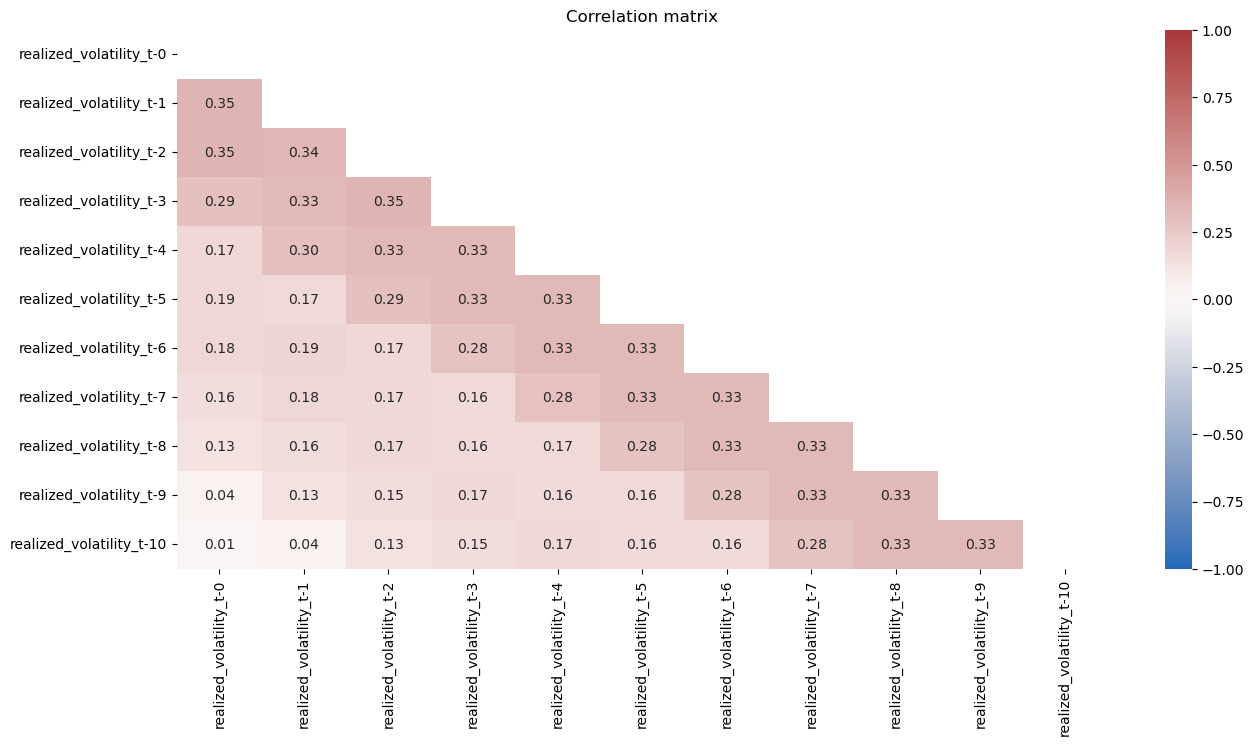

In [174]:
N_VOLATILITY_LAGS = 10
realized_volatility_lags = lag_matrix(realized_volatility,N_VOLATILITY_LAGS)

plt.figure(figsize=(15,7))
corr_matrix = realized_volatility_lags.corr(method="pearson")
matrix = np.triu(corr_matrix)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", cbar=True, mask=matrix, vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()


In [177]:
fig = px.scatter_matrix(
    realized_volatility_lags,
    width=1000,
    height=1000
    )
fig.update_traces(showlowerhalf=False)
fig.show()

In [178]:
fig = px.scatter(
    x=realized_volatility.shift(1),
    y=realized_volatility, 
    title="$(\hat{\zeta}_{t-1}, \hat{\zeta}_t)$",
    trendline="ols"
    )
fig.show()

# Scores

In [155]:
scores_path = "../../data/processed/dfpc_scores.xlsx"
df_scores = pd.read_excel(scores_path).set_index("index").iloc[:,:DHAT]

In [156]:
df_vol_scores = pd.concat([realized_volatility, df_scores], axis=1)
# Adds 1 lag
for eta in df_scores.columns:
    col_name = eta.replace("$","")
    df_vol_scores[f"{col_name}_t-1"] = df_vol_scores[eta].shift(1)
df_vol_scores.dropna(inplace=True)

corr_matrix = df_vol_scores.corr(method="pearson")
display(corr_matrix)

upper_indices = np.triu_indices_from(corr_matrix, k=1)
sorted_list = np.sort(np.abs(corr_matrix).values[upper_indices])[::-1].tolist()
print("Top absolute correlations: ", sorted_list)

,realized_volatility,$η_1$,$η_2$,$η_3$,$η_4$,$η_5$,η_1_t-1,η_2_t-1,η_3_t-1,η_4_t-1,η_5_t-1
realized_volatility,1.000000,0.913584,-0.060121,-0.170903,0.102656,0.194924,0.373732,0.022314,-0.034580,-0.006217,-0.050712
$η_1$,0.913584,1.000000,-0.105237,0.026601,0.020335,0.230834,0.453364,-0.069325,0.000796,-0.036812,-0.048323
$η_2$,-0.060121,-0.105237,1.000000,0.034614,-0.017662,-0.329758,-0.062671,0.128076,-0.022196,0.079050,-0.034585
$η_3$,-0.170903,0.026601,0.034614,1.000000,0.047011,0.057489,0.005961,-0.088214,0.264051,-0.057284,0.018118
$η_4$,0.102656,0.020335,-0.017662,0.047011,1.000000,-0.162607,-0.011154,0.031819,0.110354,0.004639,-0.040043
$η_5$,0.194924,0.230834,-0.329758,0.057489,-0.162607,1.000000,0.126750,-0.040327,0.062644,-0.007486,0.005111
η_1_t-1,0.373732,0.453364,-0.062671,0.005961,-0.011154,0.126750,1.000000,-0.112435,0.031495,0.023593,0.227306
η_2_t-1,0.022314,-0.069325,0.128076,-0.088214,0.031819,-0.040327,-0.112435,1.000000,0.020307,-0.019116,-0.334131
η_3_t-1,-0.034580,0.000796,-0.022196,0.264051,0.110354,0.062644,0.031495,0.020307,1.000000,0.054746,0.050641
η_4_t-1,-0.006217,-0.036812,0.079050,-0.057284,0.004639,-0.007486,0.023593,-0.019116,0.054746,1.000000,-0.162602


Top absolute correlations:  [0.9135835415571127, 0.4533635862421601, 0.3737318933536387, 0.3341310964690539, 0.3297584918928491, 0.26405146502639865, 0.2308338994245636, 0.22730550580442277, 0.19492355494822095, 0.17090305146796603, 0.16260664657486318, 0.16260190386115933, 0.12807559101493607, 0.12675026091015557, 0.11243536473598126, 0.11035429900587272, 0.10523663768940685, 0.10265626637751551, 0.08821409918373194, 0.07905041302605165, 0.06932481456687634, 0.06267066954136775, 0.06264363498010252, 0.060120679298385146, 0.05748860190449609, 0.05728372019305941, 0.05474639109370261, 0.050712111178142553, 0.05064093057498064, 0.048323126268521276, 0.04701070311244686, 0.04032683305010366, 0.040042967045932444, 0.03681226835207888, 0.03461367575929075, 0.03458489671289681, 0.034580012427113144, 0.03181948474944011, 0.031494877636294695, 0.026600635614796874, 0.023592529305126942, 0.022314256283452016, 0.022195917343126797, 0.02033524556409656, 0.020306708411141464, 0.019115514562312707,

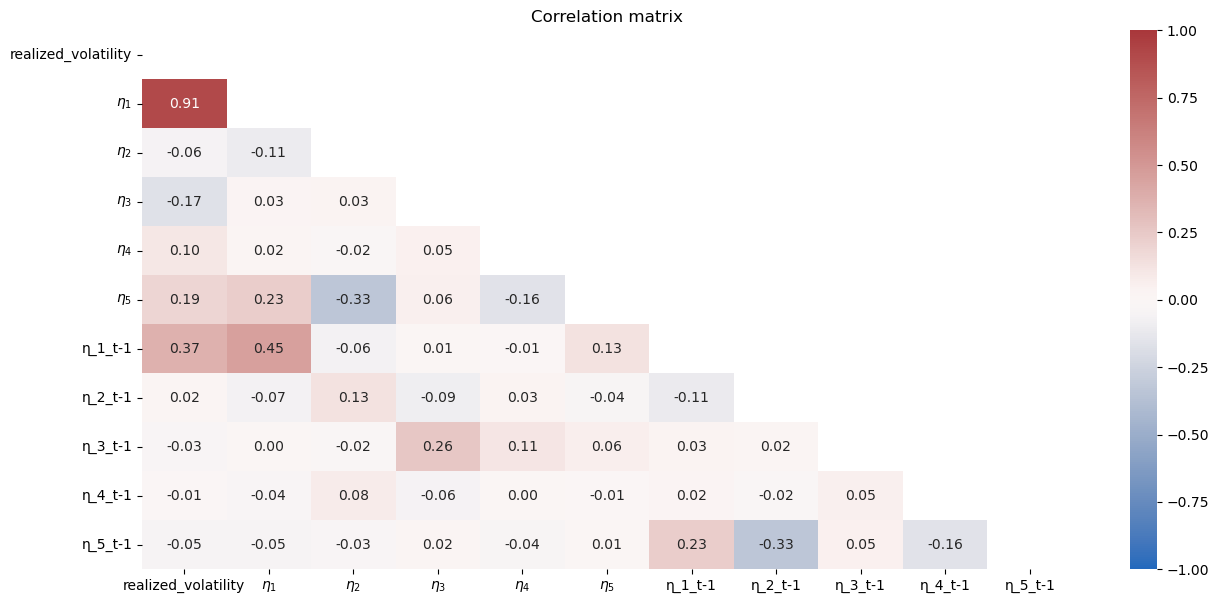

In [181]:
corr_matrix = df_vol_scores.corr()

plt.figure(figsize=(15,7))
matrix = np.triu(corr_matrix)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", cbar=True, mask=matrix, vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

In [119]:
corr_matrix = corr_matrix.mask(np.eye(corr_matrix.shape[1], dtype=bool))
c = corr_matrix.values
# Flatten the matrix into a 1D array
flattened_array = np.abs(c).flatten()

# Sort the 1D array in-place (optional, you can also use np.sort())
flattened_array.sort()

# Convert the sorted NumPy array to a standard Python list
sorted_list = flattened_array.tolist()[::-1]

print(sorted_list)

[nan, nan, nan, nan, nan, 0.9135835415571127, 0.9135835415571127, 0.4533635862421601, 0.4533635862421601, 0.3737318933536387, 0.3737318933536387, 0.12807559101493607, 0.12807559101493607, 0.11243536473598126, 0.11243536473598126, 0.10523663768940685, 0.10523663768940685, 0.06932481456687634, 0.06932481456687634, 0.06267066954136775, 0.06267066954136775, 0.060120679298385146, 0.060120679298385146, 0.022314256283452016, 0.022314256283452016]


In [182]:
fig = px.scatter_matrix(
    df_vol_scores,
    width=1000,
    height=1000
    )
fig.update_traces(showlowerhalf=False)
fig.show()

In [183]:
fig = px.scatter(
    x=df_scores.iloc[:,0].shift(1),
    y=realized_volatility, 
    title="$(\hat{\zeta}_{t-1}, \hat{\zeta}_t)$",
    trendline="ols"
    )
fig.show()